In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

project = "/content/drive/MyDrive/AODNet_data"

for root, dirs, files in os.walk(project):
    level = root.replace(project, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{indent}  {f}")

Mounted at /content/drive
AODNet_data/
  aodnet_best.pth
  SOTS/
    synthetic-objective-testing-set-sots-reside.zip
    metadata_indoor.csv
    indoor/
      clear/
      hazy/
    outdoor/
      clear/
      hazy/
  RESIDE6K/
    reside-6k.zip
    RESIDE-6K/
      test/
        GT/
        hazy/
      train/
        GT/
        hazy/
  SMOKE/
    smoke-real-dense-non-uniform-fog.zip
    test/
      clean/
      hazy/
    train/
      clean/
      hazy/


In [ ]:
!pip install torch torchvision opencv-python-headless \
             matplotlib scikit-image tqdm -q

import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
import os

os.makedirs("data", exist_ok=True)

print("Copying RESIDE-6K...")
!cp -r "/content/drive/MyDrive/AODNet_data/RESIDE6K/RESIDE-6K" data/RESIDE6K

print("Copying SOTS...")
!cp -r "/content/drive/MyDrive/AODNet_data/SOTS/outdoor" data/SOTS_outdoor

print("Copying SMOKE...")
!cp -r "/content/drive/MyDrive/AODNet_data/SMOKE" data/SMOKE

print("\nDone. Verifying:")
print("RESIDE6K train GT:",
      len(os.listdir("data/RESIDE6K/train/GT")), "images")
print("SOTS outdoor hazy:",
      len(os.listdir("data/SOTS_outdoor/hazy")), "images")

Copying RESIDE-6K...
Copying SOTS...
Copying SMOKE...

Done. Verifying:
RESIDE6K train GT: 6000 images
SOTS outdoor hazy: 500 images


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AODnet(nn.Module):
    def __init__(self):
        super(AODnet, self).__init__()
        self.conv1 = nn.Conv2d(3,  3,  kernel_size=1, padding=0)
        self.conv2 = nn.Conv2d(3,  3,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(6,  3,  kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(6,  3,  kernel_size=7, padding=3)
        self.conv5 = nn.Conv2d(12, 3,  kernel_size=3, padding=1)
        self.b = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(torch.cat([x1, x2], dim=1)))
        x4 = F.relu(self.conv4(torch.cat([x2, x3], dim=1)))
        k  = F.relu(self.conv5(torch.cat([x1, x2, x3, x4], dim=1)))
        return k * x - k + self.b

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AODnet().to(device)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/AODNet_data/aodnet_best.pth",
    map_location=device
))
model.eval()

print(f"Loaded on   : {device}")
print(f"b value     : {model.b.item():.4f}")
print(f"Params      : {sum(p.numel() for p in model.parameters()):,}")

Loaded on   : cuda
b value     : 1.0425
Params      : 1,762


In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class DehazingDataset(Dataset):
    def __init__(self, hazy_dir, clear_dir, size=256, naming="direct"):
        self.hazy_dir  = hazy_dir
        self.clear_dir = clear_dir
        self.naming    = naming
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
        ])
        all_hazy = sorted([
            f for f in os.listdir(hazy_dir)
            if f.lower().endswith(('.jpg','.png','.jpeg'))
        ])
        self.pairs = []
        skipped = 0
        for hazy_name in all_hazy:
            clear_name = self._get_clear_name(hazy_name)
            if os.path.exists(os.path.join(clear_dir, clear_name)):
                self.pairs.append((hazy_name, clear_name))
            else:
                skipped += 1
        print(f"  {len(self.pairs)} valid pairs ({skipped} skipped)")

    def _get_clear_name(self, hazy_name):
        if self.naming == "reside":
            base = hazy_name.split('_')[0]
            for ext in ['.png', '.jpg', '.jpeg']:
                if os.path.exists(os.path.join(self.clear_dir, base + ext)):
                    return base + ext
            return base + '.png'
        return hazy_name

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        hazy_name, clear_name = self.pairs[idx]
        hazy  = Image.open(
            os.path.join(self.hazy_dir,  hazy_name)).convert('RGB')
        clear = Image.open(
            os.path.join(self.clear_dir, clear_name)).convert('RGB')
        return self.transform(hazy), self.transform(clear)

# Build test loader for evaluation
print("SOTS outdoor (test):")
test_dataset = DehazingDataset(
    hazy_dir  = "data/SOTS_outdoor/hazy",
    clear_dir = "data/SOTS_outdoor/clear",
    naming    = "reside"
)
test_loader = DataLoader(test_dataset, batch_size=8,
                         shuffle=False, num_workers=2)

SOTS outdoor (test):
  500 valid pairs (0 skipped)


In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import numpy as np

def evaluate(model, loader, device, n_batches=10):
    model.eval()
    psnr_scores, ssim_scores = [], []
    with torch.no_grad():
        for i, (hazy, clear) in enumerate(loader):
            if i >= n_batches:
                break
            hazy, clear = hazy.to(device), clear.to(device)
            output = model(hazy).clamp(0, 1)
            for j in range(output.shape[0]):
                out_np = output[j].cpu().numpy().transpose(1,2,0)
                gt_np  = clear[j].cpu().numpy().transpose(1,2,0)
                psnr_scores.append(psnr_fn(gt_np, out_np, data_range=1.0))
                ssim_scores.append(ssim_fn(gt_np, out_np,
                                   channel_axis=2, data_range=1.0))
    return np.mean(psnr_scores), np.mean(ssim_scores)

psnr_val, ssim_val = evaluate(model, test_loader, device)
print(f"Baseline — PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}")
# Should be close to 22.27 dB

Baseline — PSNR: 21.85 dB | SSIM: 0.9121


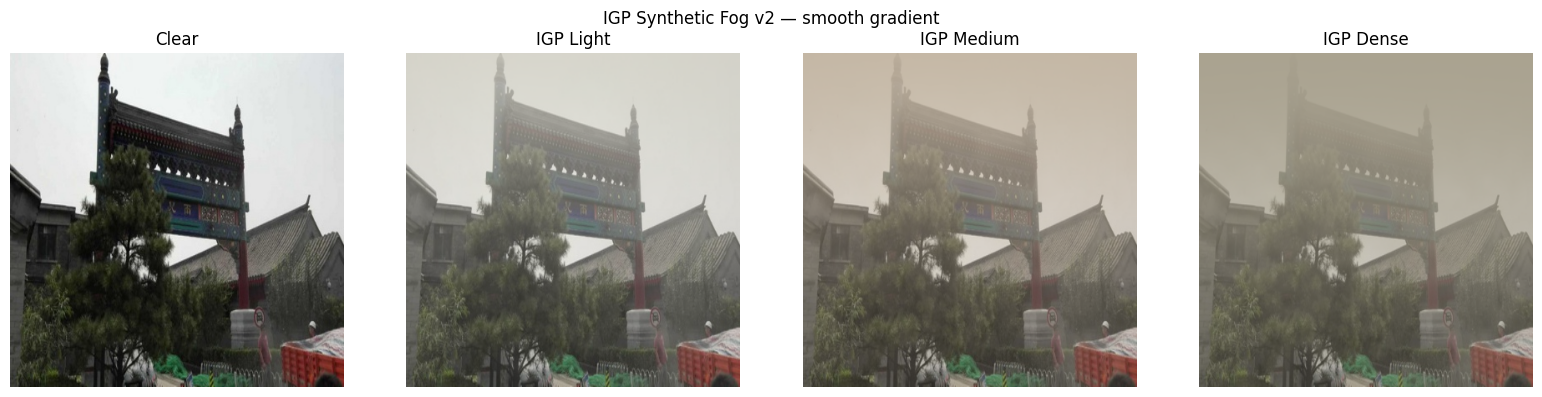

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def synthesize_igp_fog(clear_img_np, fog_density="medium"):
    h, w = clear_img_np.shape[:2]

    # IGP atmospheric light — grey-brown tint
    A_options = {
        "light"  : np.array([0.82, 0.80, 0.76]),
        "medium" : np.array([0.76, 0.72, 0.65]),
        "dense"  : np.array([0.68, 0.63, 0.55]),
    }
    A  = A_options[fog_density].copy()
    A += np.random.uniform(-0.02, 0.02, 3)
    A  = np.clip(A, 0, 1)

    # ── Smooth depth map — no hard bands ─────────────────────────
    # Vertical gradient: top (horizon) = far = more fog
    y_coords = np.linspace(0, 1, h).reshape(-1, 1)
    y_coords = np.tile(y_coords, (1, w))

    # Exponential falloff — fog much denser at top, fades near camera
    depth = 2.5 * np.exp(-3.0 * y_coords) + 0.1

    # Smooth spatial variation — gentle patches, NOT grain
    # Use low-frequency noise by downsampling then upsampling
    small_h, small_w = h // 16, w // 16
    small_noise = np.random.uniform(-0.2, 0.2, (small_h, small_w))
    smooth_noise = np.array(
        Image.fromarray(
            ((small_noise + 0.2) * 127.5).astype(np.uint8)
        ).resize((w, h), Image.BILINEAR),
        dtype=np.float32
    ) / 127.5 - 0.2

    depth = np.clip(depth + smooth_noise * 0.3, 0.05, 3.0)

    # Transmission map
    beta_options = {"light": 0.7, "medium": 1.1, "dense": 1.7}
    beta = beta_options[fog_density] + np.random.uniform(-0.05, 0.05)
    t    = np.exp(-beta * depth)
    t    = np.stack([t, t, t], axis=2)

    # Atmospheric scattering: I = J*t + A*(1-t)
    J = clear_img_np.astype(np.float32) / 255.0
    I = J * t + A * (1 - t)
    return np.clip(I * 255, 0, 255).astype(np.uint8)


# ── Visual check ──────────────────────────────────────────────────
sample_path = "data/RESIDE6K/train/GT/1.jpg"
clear_np    = np.array(Image.open(sample_path).convert("RGB"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(clear_np);                               axes[0].set_title("Clear")
axes[1].imshow(synthesize_igp_fog(clear_np, "light"));  axes[1].set_title("IGP Light")
axes[2].imshow(synthesize_igp_fog(clear_np, "medium")); axes[2].set_title("IGP Medium")
axes[3].imshow(synthesize_igp_fog(clear_np, "dense"));  axes[3].set_title("IGP Dense")
for ax in axes: ax.axis("off")
plt.suptitle("IGP Synthetic Fog v2 — smooth gradient", fontsize=12)
plt.tight_layout()
plt.savefig("igp_fog_v2.png", dpi=150)
plt.show()

In [ ]:
import os
import numpy as np
from PIL import Image

def build_igp_dataset(clear_dir, output_dir):
    os.makedirs(f"{output_dir}/hazy",  exist_ok=True)
    os.makedirs(f"{output_dir}/clear", exist_ok=True)

    clear_imgs = sorted([
        f for f in os.listdir(clear_dir)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ])

    count = 0
    for fname in clear_imgs:
        clear_np = np.array(
            Image.open(os.path.join(clear_dir, fname)).convert("RGB"))
        for density in ["light", "medium", "dense"]:
            stem     = os.path.splitext(fname)[0]
            out_name = f"{stem}_{density}.png"
            Image.fromarray(
                synthesize_igp_fog(clear_np, density)
            ).save(f"{output_dir}/hazy/{out_name}")
            Image.fromarray(clear_np).save(
                f"{output_dir}/clear/{out_name}")
            count += 1
        if count % 300 == 0:
            print(f"  Generated {count} pairs...")

    print(f"\nDone — {count} IGP fog pairs from {len(clear_imgs)} images")

build_igp_dataset(
    clear_dir  = "data/RESIDE6K/train/GT",
    output_dir = "data/IGP_synthetic"
)

  Generated 300 pairs...
  Generated 600 pairs...
  Generated 900 pairs...
  Generated 1200 pairs...
  Generated 1500 pairs...
  Generated 1800 pairs...
  Generated 2100 pairs...
  Generated 2400 pairs...
  Generated 2700 pairs...
  Generated 3000 pairs...
  Generated 3300 pairs...
  Generated 3600 pairs...
  Generated 3900 pairs...
  Generated 4200 pairs...
  Generated 4500 pairs...
  Generated 4800 pairs...
  Generated 5100 pairs...
  Generated 5400 pairs...
  Generated 5700 pairs...
  Generated 6000 pairs...
  Generated 6300 pairs...
  Generated 6600 pairs...
  Generated 6900 pairs...
  Generated 7200 pairs...
  Generated 7500 pairs...
  Generated 7800 pairs...
  Generated 8100 pairs...
  Generated 8400 pairs...
  Generated 8700 pairs...
  Generated 9000 pairs...
  Generated 9300 pairs...
  Generated 9600 pairs...
  Generated 9900 pairs...
  Generated 10200 pairs...
  Generated 10500 pairs...
  Generated 10800 pairs...
  Generated 11100 pairs...
  Generated 11400 pairs...
  Generate

In [ ]:
print("Backing up IGP dataset to Drive...")
!cp -r data/IGP_synthetic \
    "/content/drive/MyDrive/AODNet_data/IGP_synthetic"
print("Done — safe from session resets")

Backing up IGP dataset to Drive...
Done — safe from session resets
